# 関係研究の準備：行列と有向グラフ

対応章：[40_network_foundations.md](../chapters/40_network_foundations.md)

3頂点の仮想ネットワークを，有向グラフと隣接行列の両方で表す．さらに，行列積から各頂点へ入る影響を求め，陽的Euler法で1ステップだけ状態を更新する．

## 隣接行列を定義する

本章では $A_{ij}$ を頂点 $j$ から頂点 $i$ への影響とする．したがって，行は影響を受ける頂点，列は影響を与える頂点である．正の辺と負の辺を含む仮想例を使う．

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

A = np.array([
    [0.0,  0.8, 0.0],
    [0.0, 0.0, 0.6],
    [-0.5, 0.0, 0.0],
])
x = np.array([1.0, -0.5, 0.25])

print('A =')
print(A)
print('x =', x)
print('A @ x =', A @ x)

A =
[[ 0.   0.8  0. ]
 [ 0.   0.   0.6]
 [-0.5  0.   0. ]]
x = [ 1.   -0.5   0.25]
A @ x = [-0.4   0.15 -0.5 ]


## グラフと行列を照合する

左図では青が正の影響，赤が負の影響を表す．矢印 $j\to i$ の値が，右図の第 $i$ 行，第 $j$ 列に置かれていることを1本ずつ確認する．

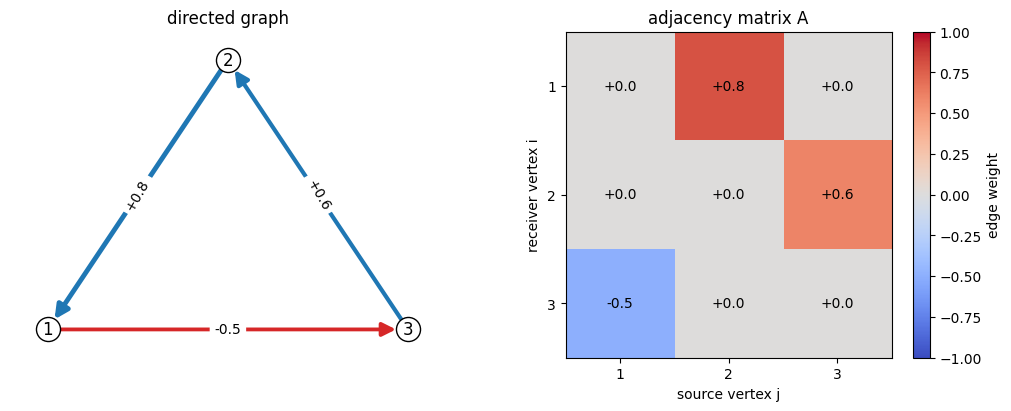

In [2]:
graph = nx.DiGraph()
graph.add_nodes_from(range(1, 4))
for receiver in range(3):
    for source in range(3):
        if A[receiver, source] != 0:
            graph.add_edge(source + 1, receiver + 1, weight=A[receiver, source])

positions = {1: (-1.0, 0.0), 2: (0.0, 0.8), 3: (1.0, 0.0)}
edges = list(graph.edges(data=True))
edge_colors = ['tab:blue' if data['weight'] > 0 else 'tab:red' for _, _, data in edges]
edge_widths = [1.5 + 2.5 * abs(data['weight']) for _, _, data in edges]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
nx.draw_networkx(
    graph,
    pos=positions,
    ax=axes[0],
    node_color='white',
    edgecolors='black',
    edge_color=edge_colors,
    width=edge_widths,
    arrowsize=20,
)
edge_labels = {
    (source, receiver): f'{data["weight"]:+.1f}'
    for source, receiver, data in edges
}
nx.draw_networkx_edge_labels(graph, positions, edge_labels=edge_labels, ax=axes[0])
axes[0].set_title('directed graph')
axes[0].axis('off')

image = axes[1].imshow(A, cmap='coolwarm', vmin=-1.0, vmax=1.0)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f'{A[i, j]:+.1f}', ha='center', va='center')
axes[1].set_xticks(range(3), labels=['1', '2', '3'])
axes[1].set_yticks(range(3), labels=['1', '2', '3'])
axes[1].set_xlabel('source vertex j')
axes[1].set_ylabel('receiver vertex i')
axes[1].set_title('adjacency matrix A')
fig.colorbar(image, ax=axes[1], label='edge weight')
plt.show()

## 1ステップの変化を計算する

$d\mathbf{x}/dt=(-\alpha I+\beta A)\mathbf{x}$ を用いる．自己減衰とネットワークから入る影響を別々に表示してから，時間刻み $\Delta t$ で1ステップ進める．

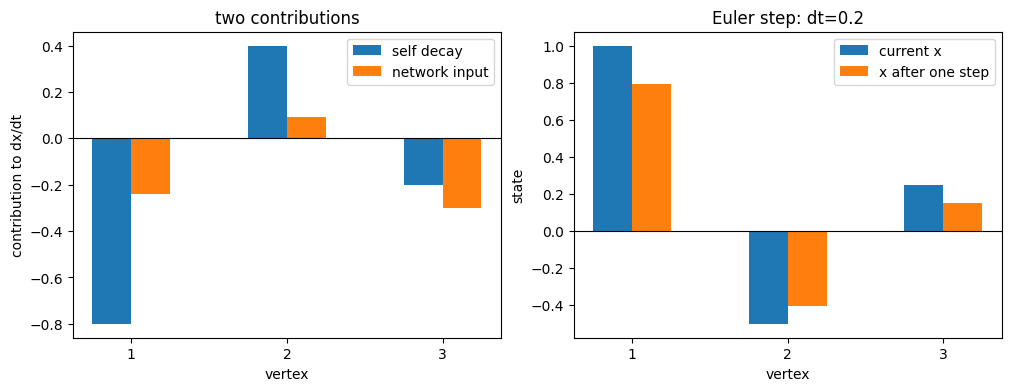

self decay   = [-0.8  0.4 -0.2]
network input = [-0.24  0.09 -0.3 ]
dx/dt         = [-1.04  0.49 -0.5 ]
x_next        = [ 0.792 -0.402  0.15 ]


In [3]:
alpha = 0.8
beta = 0.6
dt = 0.2

self_decay = -alpha * x
network_input = beta * (A @ x)
dxdt = self_decay + network_input
x_next = x + dt * dxdt

vertex = np.arange(3)
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
axes[0].bar(vertex - width / 2, self_decay, width, label='self decay')
axes[0].bar(vertex + width / 2, network_input, width, label='network input')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(vertex, labels=['1', '2', '3'])
axes[0].set_xlabel('vertex')
axes[0].set_ylabel('contribution to dx/dt')
axes[0].set_title('two contributions')
axes[0].legend()

axes[1].bar(vertex - width / 2, x, width, label='current x')
axes[1].bar(vertex + width / 2, x_next, width, label='x after one step')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(vertex, labels=['1', '2', '3'])
axes[1].set_xlabel('vertex')
axes[1].set_ylabel('state')
axes[1].set_title(f'Euler step: dt={dt}')
axes[1].legend()
plt.show()

print('self decay   =', np.round(self_decay, 3))
print('network input =', np.round(network_input, 3))
print('dx/dt         =', np.round(dxdt, 3))
print('x_next        =', np.round(x_next, 3))

## 課題

1. Aの第1行第2列の値と，グラフ上の対応する矢印を答える．値の符号も説明する．
2. 行列積 $A\mathbf{x}$ の第2成分を手計算し，Pythonの出力と照合する．
3. betaを0として1ステップ進め，3頂点すべてが原点へ近づくことを確認する．
4. Aの第3行第1列を-0.5から+0.5へ変える．頂点3のnetwork_inputがどのように変わるか，実行前に予想する．
5. dtを0.2から1.0へ変え，1ステップの変化が大きくなることを確認する．時間刻みはモデルの係数ではなく数値計算の設定であることを説明する．